In [1]:
# 3열 CSV 파일의 3번째 열 X(Zim)를 -X(-Zim)로 변환하는 코드입니다.
# CSV 파일은 1열 Hz, 2열 R(Zre), 3열 X(Zim) 형식이라고 가정합니다.
# 변환된 파일은 원본 폴더 이름 뒤에 _converted를 붙인 새 폴더에 저장하고, Nyquist plot도 함께 그립니다.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# ====== 1. 원본 CSV 폴더 경로 설정 ======
folder_path = r"C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1. ionic DC-TENG\0. 실험자료\8. Gibeom touch\260413_몰당 저항 3차\원본 csv\RX"

# ====== 2. Nyquist plot에 사용할 주파수 범위 설정 ======
freq_min = 20
freq_max = 2_000_000



원본 폴더: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1. ionic DC-TENG\0. 실험자료\8. Gibeom touch\260413_몰당 저항 3차\원본 csv\RX
저장 폴더: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1. ionic DC-TENG\0. 실험자료\8. Gibeom touch\260413_몰당 저항 3차\원본 csv\RX_Nyquist
대상 파일 수: 10
모든 CSV 파일이 3열 형식임을 확인했습니다.

Processing: 0.5M_RX (2).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1. ionic DC-TENG\0. 실험자료\8. Gibeom touch\260413_몰당 저항 3차\원본 csv\RX_Nyquist\0.5M_RX (2).csv


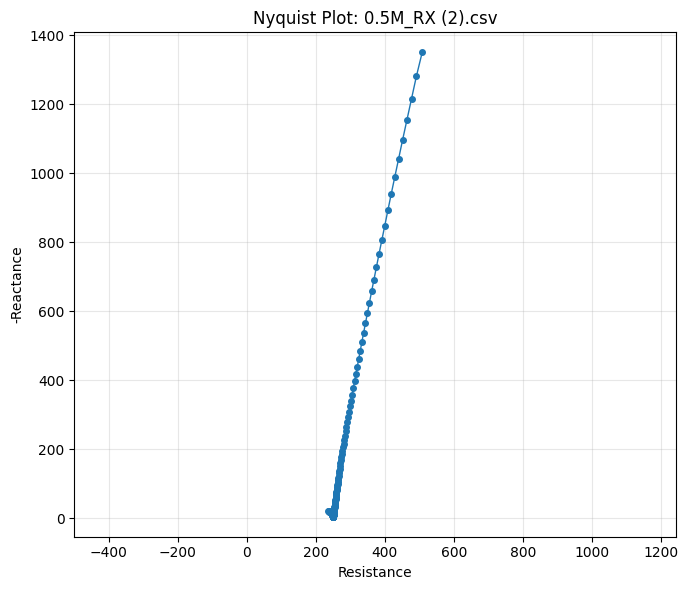

Processing: 0.5M_RX.csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1. ionic DC-TENG\0. 실험자료\8. Gibeom touch\260413_몰당 저항 3차\원본 csv\RX_Nyquist\0.5M_RX.csv


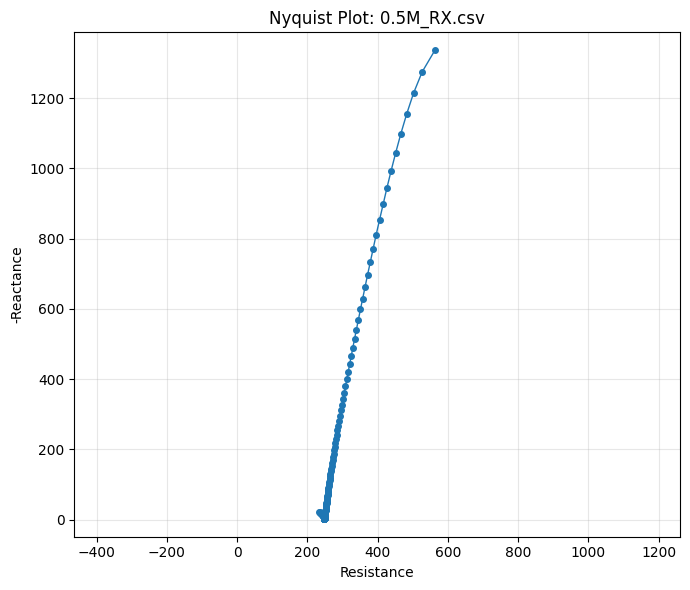

Processing: 0M_RX (2).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1. ionic DC-TENG\0. 실험자료\8. Gibeom touch\260413_몰당 저항 3차\원본 csv\RX_Nyquist\0M_RX (2).csv


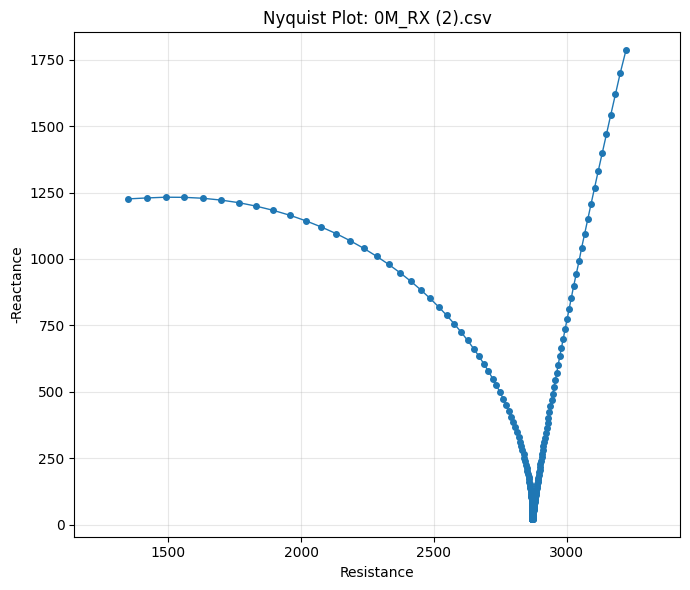

Processing: 0M_RX.csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1. ionic DC-TENG\0. 실험자료\8. Gibeom touch\260413_몰당 저항 3차\원본 csv\RX_Nyquist\0M_RX.csv


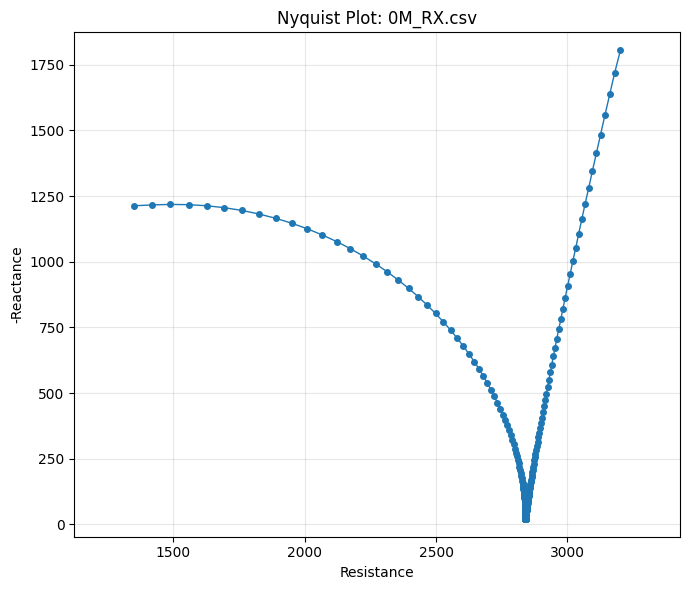

Processing: 1.5M_RX (2).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1. ionic DC-TENG\0. 실험자료\8. Gibeom touch\260413_몰당 저항 3차\원본 csv\RX_Nyquist\1.5M_RX (2).csv


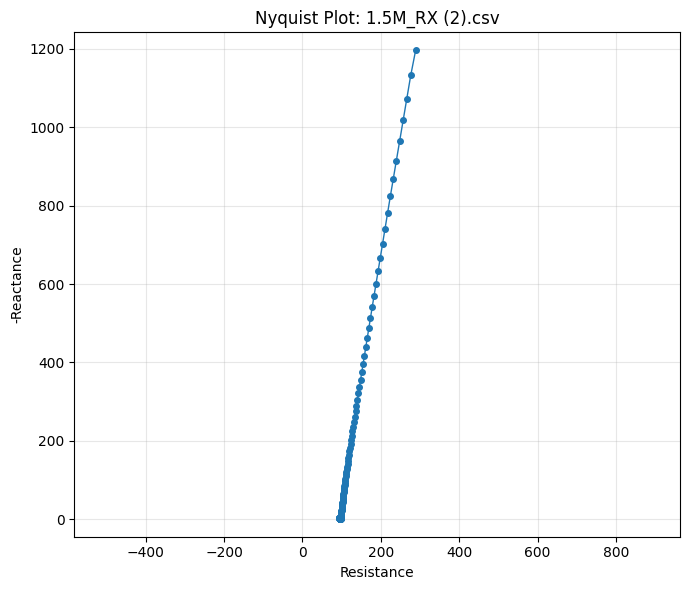

Processing: 1.5M_RX.csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1. ionic DC-TENG\0. 실험자료\8. Gibeom touch\260413_몰당 저항 3차\원본 csv\RX_Nyquist\1.5M_RX.csv


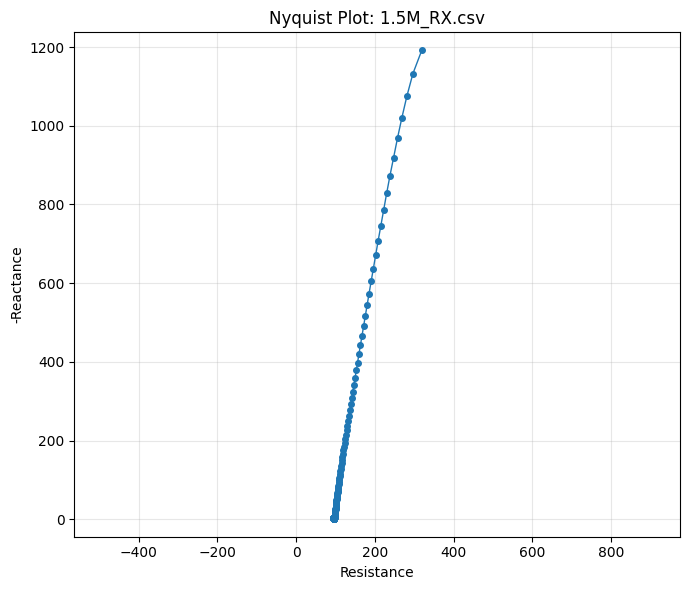

Processing: 1M_RX (2).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1. ionic DC-TENG\0. 실험자료\8. Gibeom touch\260413_몰당 저항 3차\원본 csv\RX_Nyquist\1M_RX (2).csv


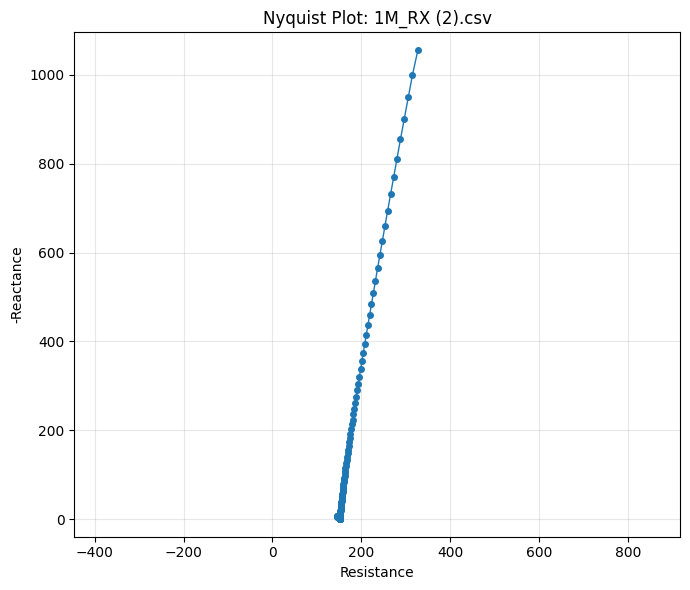

Processing: 1M_RX.csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1. ionic DC-TENG\0. 실험자료\8. Gibeom touch\260413_몰당 저항 3차\원본 csv\RX_Nyquist\1M_RX.csv


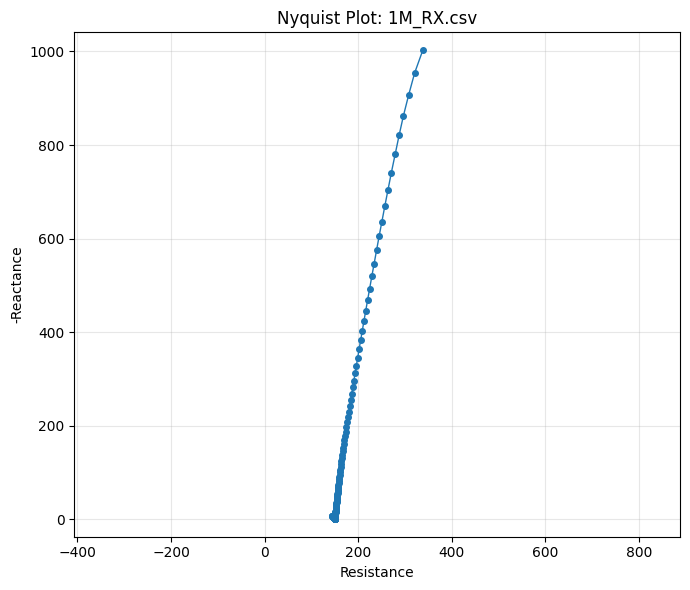

Processing: 2M_RX (2).csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1. ionic DC-TENG\0. 실험자료\8. Gibeom touch\260413_몰당 저항 3차\원본 csv\RX_Nyquist\2M_RX (2).csv


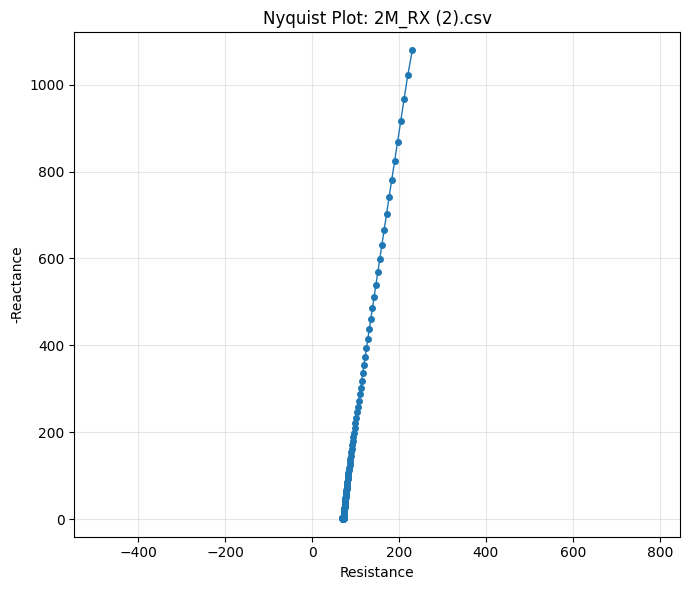

Processing: 2M_RX.csv
  -> 저장 완료: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1. ionic DC-TENG\0. 실험자료\8. Gibeom touch\260413_몰당 저항 3차\원본 csv\RX_Nyquist\2M_RX.csv


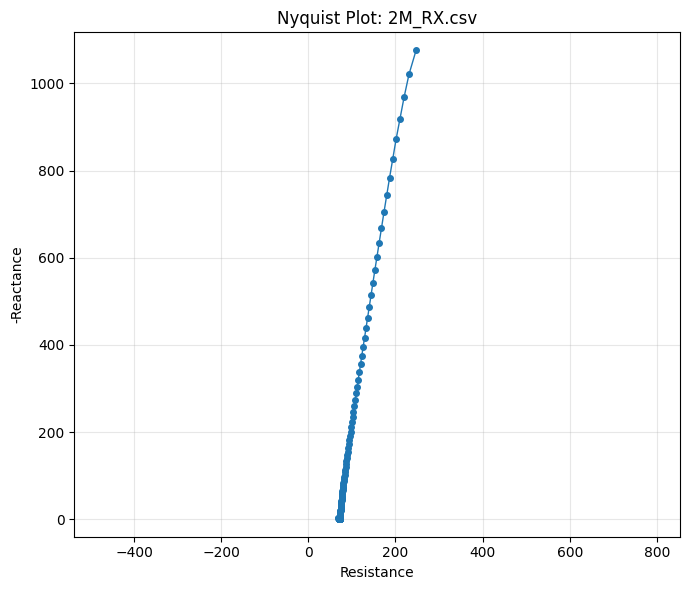

모든 CSV 파일의 R-X -> R-(-X) 변환 및 Nyquist plot 생성이 완료되었습니다.


In [3]:
folder_path = Path(folder_path)
output_folder = folder_path.parent / f"{folder_path.name}_Nyquist"
output_folder.mkdir(parents=True, exist_ok=True)

csv_files = sorted(folder_path.glob("*.csv"))

print(f"원본 폴더: {folder_path}")
print(f"저장 폴더: {output_folder}")
print(f"대상 파일 수: {len(csv_files)}")

# ====== 🔒 안전장치: 모든 파일이 정확히 3열인지 사전 검사 ======
for file_path in csv_files:
    df_check = pd.read_csv(file_path, header=None)

    if df_check.shape[1] != 3:
        raise ValueError(
            f"{file_path.name} → 열 개수가 {df_check.shape[1]}개입니다. 반드시 3열(Hz, R, X)이어야 합니다."
        )

print("모든 CSV 파일이 3열 형식임을 확인했습니다.\n")

# ====== 기존 처리 ======
for file_path in csv_files:
    print(f"Processing: {file_path.name}")

    df = pd.read_csv(file_path, header=None)

    freq = pd.to_numeric(df.iloc[:, 0], errors="coerce")
    resistance = pd.to_numeric(df.iloc[:, 1], errors="coerce")
    reactance = pd.to_numeric(df.iloc[:, 2], errors="coerce")

    converted_df = pd.DataFrame(
        {
            "Hz": freq,
            "resistance": resistance,
            "-reactance": -reactance,
        }
    ).dropna()

    if converted_df.empty:
        print("  -> 건너뜀: 유효한 숫자 데이터가 없습니다.")
        continue

    output_path = output_folder / file_path.name
    converted_df.to_csv(output_path, index=False)
    print(f"  -> 저장 완료: {output_path}")

    plot_df = converted_df[
        (converted_df["Hz"] >= freq_min) & (converted_df["Hz"] <= freq_max)
    ]

    if plot_df.empty:
        print(f"  -> Plot 생략: 설정한 주파수 범위({freq_min} Hz ~ {freq_max} Hz)에 해당하는 데이터가 없습니다.")
        continue

    plt.figure(figsize=(7, 6))
    plt.plot(
        plot_df["resistance"],
        plot_df["-reactance"],
        marker="o",
        linestyle="-",
        markersize=4,
        linewidth=1,
    )
    plt.xlabel("Resistance")
    plt.ylabel("-Reactance")
    plt.title(f"Nyquist Plot: {file_path.name}")
    plt.grid(True, alpha=0.3)
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

print("모든 CSV 파일의 R-X -> R-(-X) 변환 및 Nyquist plot 생성이 완료되었습니다.")